# Projeto C318 - Previsão de Salários no Mercado de IA

**Objetivo**: Desenvolver um modelo preditivo para estimar o salário anual de vagas na área de IA/dados.

**Tipo de Problema**: Regressão

**Variável Alvo**: `salary`

---

## Sumário
1. Configuração e Reprodutibilidade
2. Carregamento dos Dados
3. Análise Exploratória (EDA)
4. Pré-processamento
5. Modelagem Supervisionada
6. Otimização de Hiperparâmetros
7. Modelagem Não Supervisionada
8. Conclusões

---
## 1. Configuração e Reprodutibilidade

In [43]:
# ============================================================
# SEED GLOBAL - Garantir reprodutibilidade
# ============================================================
SEED = 67

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# Imports
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import pandas as pd

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# XGBoost
from xgboost import XGBRegressor

# Statsmodels para VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Configuração concluída!")
print(f"Seed global: {SEED}")

Configuração concluída!
Seed global: 67


---
## 2. Carregamento dos Dados

In [44]:
# Carregar dataset
df = pd.read_csv('../data/AI Job Market Dataset.csv')

print(f"Shape: {df.shape}")
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

Shape: (10345, 19)
Linhas: 10,345
Colunas: 19


In [45]:
# Visualizar primeiras linhas
df.head(10)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
5,6,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6,Master,1,0,1,1,0,165878,5,2021,High,2
6,7,Data Scientist,MNC,Technology,Germany,Remote,Entry,14,Bachelor,0,0,0,0,0,67027,8,2026,High,8
7,8,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4,PhD,1,0,1,0,1,78392,8,2023,High,7
8,9,Machine Learning Engineer,Startup,Education,Canada,Onsite,Mid,2,PhD,0,0,0,0,1,123840,5,2021,Low,3
9,10,Data Engineer,Enterprise,Retail,USA,Onsite,Senior,9,Master,1,0,0,0,1,112408,4,2024,High,7


In [46]:
# Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [47]:
# Estatísticas descritivas
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Verificação de Valores Faltantes

In [48]:
# Valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Percentual (%)': missing_pct
})

print("Valores Faltantes por Coluna:")
print(missing_df[missing_df['Faltantes'] > 0] if missing.sum() > 0 else "Nenhum valor faltante!")

Valores Faltantes por Coluna:
Nenhum valor faltante!


### 3.2 Análise da Variável Alvo (salary)

In [49]:
# Estatísticas do salary
print("Estatísticas do Salário:")
print(f"  Mínimo:  ${df['salary'].min():,.0f}")
print(f"  Máximo:  ${df['salary'].max():,.0f}")
print(f"  Média:   ${df['salary'].mean():,.0f}")
print(f"  Mediana: ${df['salary'].median():,.0f}")
print(f"  Desvio:  ${df['salary'].std():,.0f}")

Estatísticas do Salário:
  Mínimo:  $45,083
  Máximo:  $204,143
  Média:   $113,438
  Mediana: $113,082
  Desvio:  $31,389


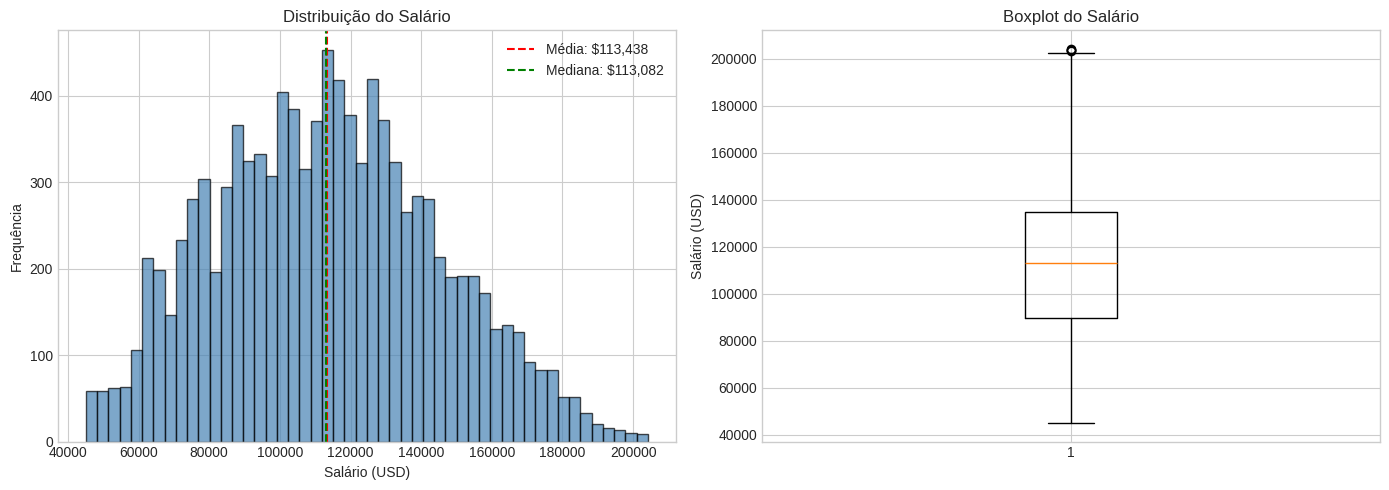

In [50]:
# Distribuição do salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['salary'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Salário (USD)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Salário')
axes[0].axvline(df['salary'].mean(), color='red', linestyle='--', label=f"Média: ${df['salary'].mean():,.0f}")
axes[0].axvline(df['salary'].median(), color='green', linestyle='--', label=f"Mediana: ${df['salary'].median():,.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['salary'], vert=True)
axes[1].set_ylabel('Salário (USD)')
axes[1].set_title('Boxplot do Salário')

plt.tight_layout()
plt.savefig('../reports/salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Análise das Variáveis Categóricas

In [51]:
# Variáveis categóricas
cat_cols = ['job_title', 'company_size', 'company_industry', 'country', 
            'remote_type', 'experience_level', 'education_level', 'hiring_urgency']

print("Valores únicos por variável categórica:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Valores únicos por variável categórica:

job_title:
job_title
Business Analyst             1773
AI Engineer                  1742
Machine Learning Engineer    1740
Data Analyst                 1711
Data Scientist               1703
Data Engineer                1676
Name: count, dtype: int64

company_size:
company_size
Startup       2656
MNC           2593
Medium        2548
Enterprise    2548
Name: count, dtype: int64

company_industry:
company_industry
Technology    1787
E-commerce    1744
Finance       1724
Healthcare    1715
Education     1704
Retail        1671
Name: count, dtype: int64

country:
country
Germany      1498
Singapore    1490
Canada       1488
UK           1485
India        1470
USA          1459
Australia    1455
Name: count, dtype: int64

remote_type:
remote_type
Remote    3513
Hybrid    3420
Onsite    3412
Name: count, dtype: int64

experience_level:
experience_level
Entry     3513
Senior    3420
Mid       3412
Name: count, dtype: int64

education_level:
education_

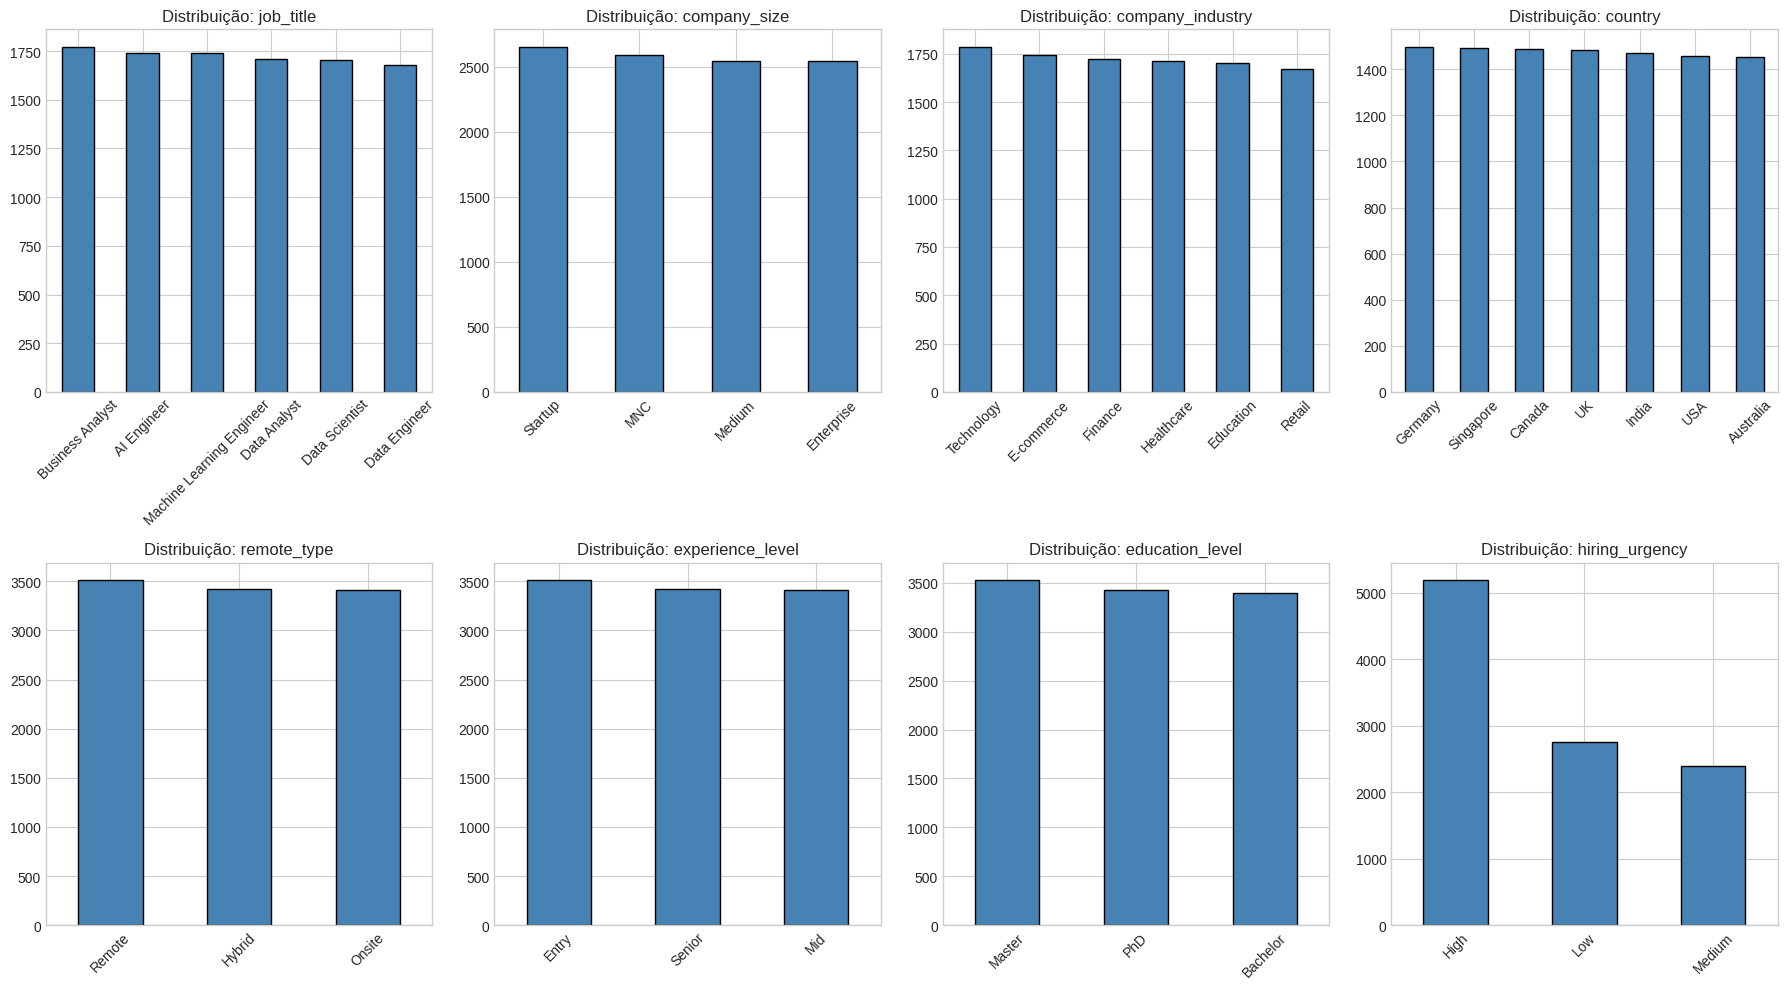

In [52]:
# Gráficos de barras para variáveis categóricas
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Salário por Categoria

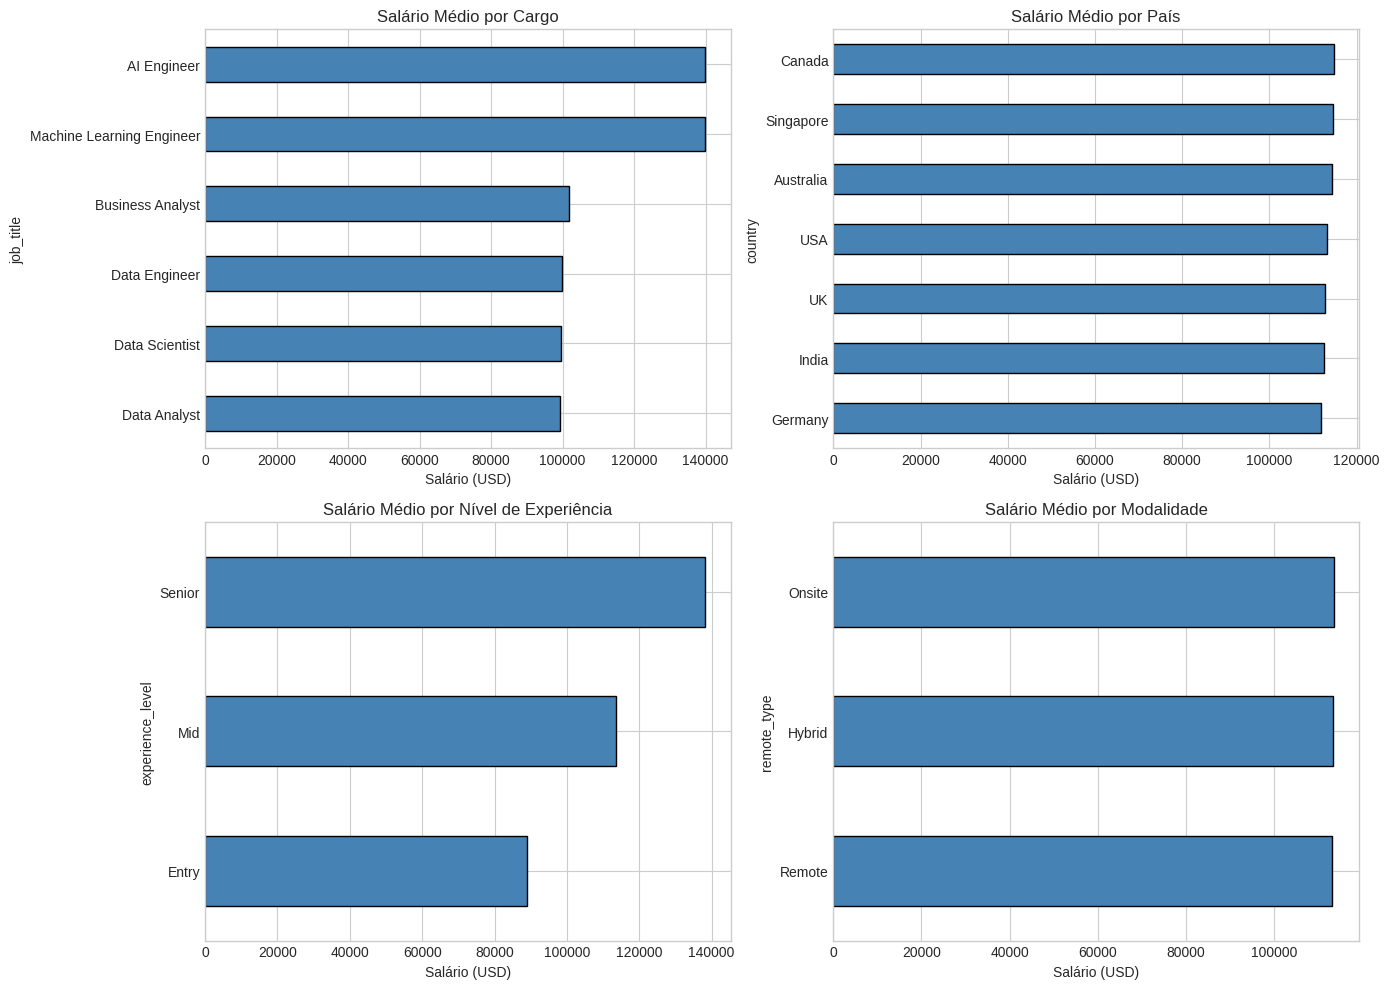

In [53]:
    # Salário médio por job_title
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Por cargo
    df.groupby('job_title')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Salário Médio por Cargo')
    axes[0, 0].set_xlabel('Salário (USD)')

    # Por país
    df.groupby('country')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[0, 1], color='steelblue', edgecolor='black')
    axes[0, 1].set_title('Salário Médio por País')
    axes[0, 1].set_xlabel('Salário (USD)')

    # Por nível de experiência
    df.groupby('experience_level')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[1, 0], color='steelblue', edgecolor='black')
    axes[1, 0].set_title('Salário Médio por Nível de Experiência')
    axes[1, 0].set_xlabel('Salário (USD)')

    # Por modalidade de trabalho
    df.groupby('remote_type')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[1, 1], color='steelblue', edgecolor='black')
    axes[1, 1].set_title('Salário Médio por Modalidade')
    axes[1, 1].set_xlabel('Salário (USD)')

    plt.tight_layout()
    plt.savefig('../reports/salary_by_category.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.5 Análise das Skills

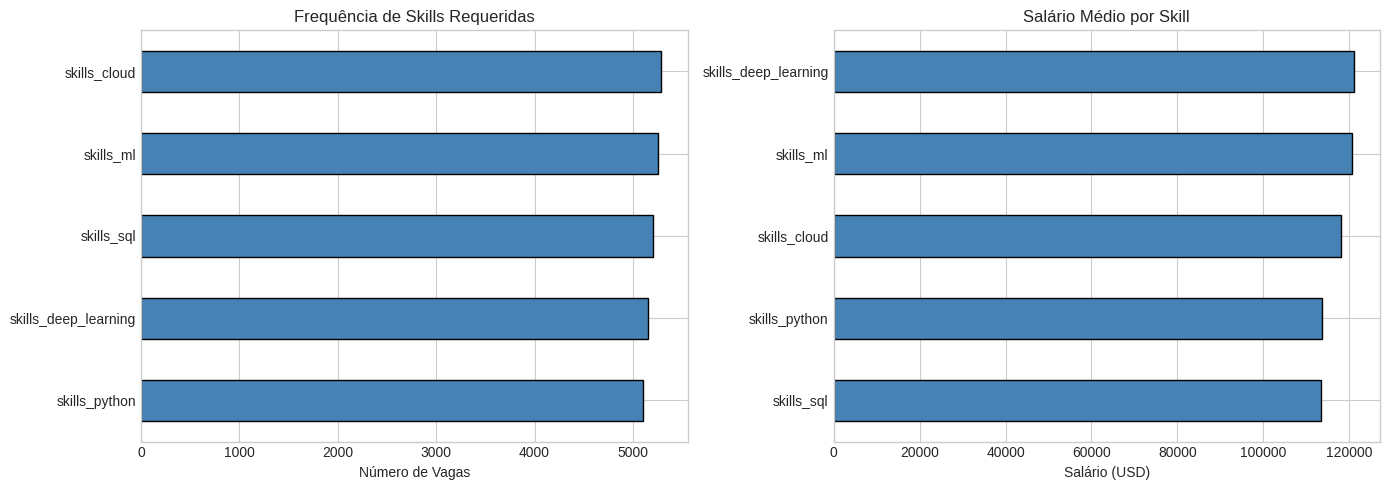

In [54]:
# Skills binárias
skills_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Frequência de cada skill
skills_freq = df[skills_cols].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequência
skills_freq.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Frequência de Skills Requeridas')
axes[0].set_xlabel('Número de Vagas')

# Impacto no salário
skill_salary = {}
for skill in skills_cols:
    skill_salary[skill] = df[df[skill] == 1]['salary'].mean()

pd.Series(skill_salary).sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Salário Médio por Skill')
axes[1].set_xlabel('Salário (USD)')

plt.tight_layout()
plt.savefig('../reports/skills_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Matriz de Correlação

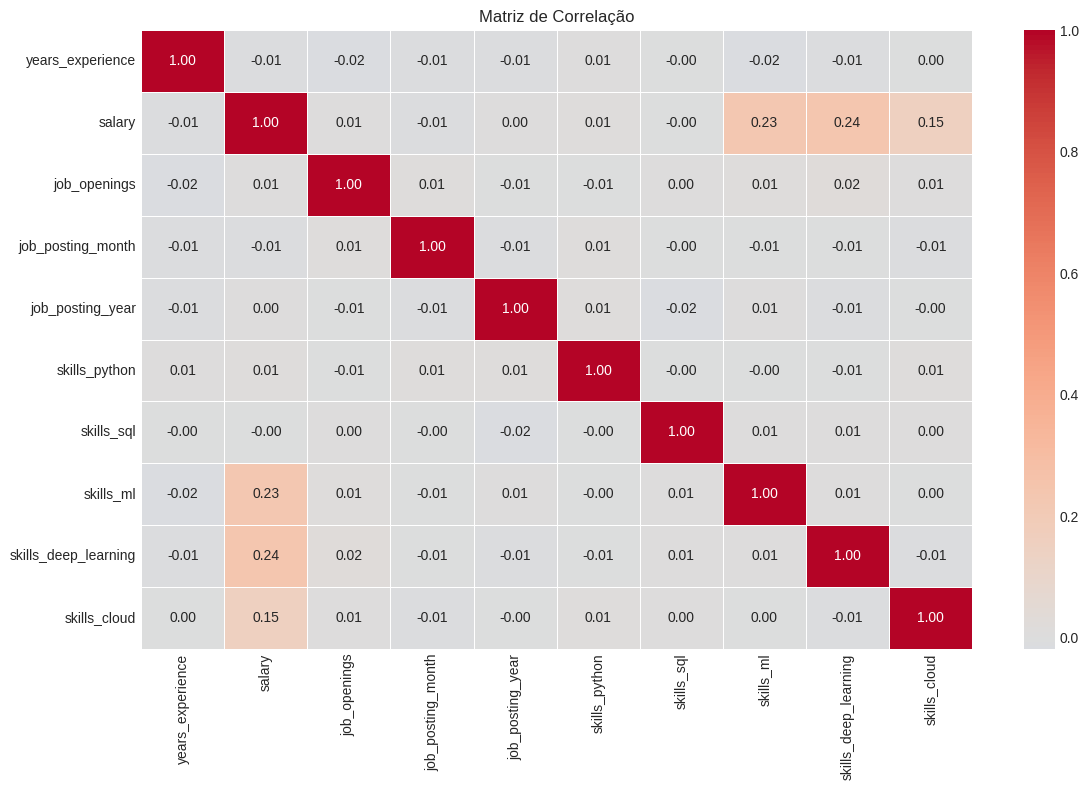

In [55]:
# Selecionar apenas colunas numéricas
numeric_cols = ['years_experience', 'salary', 'job_openings', 'job_posting_month', 'job_posting_year'] + skills_cols

# Matriz de correlação
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Análise de Duplicatas

In [56]:
# Verificar duplicatas
duplicatas_total = df.duplicated().sum()
duplicatas_sem_id = df.drop(columns=['job_id']).duplicated().sum()

print("Análise de Duplicatas:")
print(f"  Linhas duplicadas (todas as colunas): {duplicatas_total}")
print(f"  Linhas duplicadas (excluindo job_id): {duplicatas_sem_id}")

if duplicatas_sem_id > 0:
    print(f"\n  ATENÇÃO: {duplicatas_sem_id} linhas duplicadas encontradas!")
    print("  Exemplos de duplicatas:")
    duplicadas = df[df.drop(columns=['job_id']).duplicated(keep=False)]
    print(duplicadas.head(10))
else:
    print("\n  ✓ Nenhuma duplicata encontrada no dataset.")

Análise de Duplicatas:
  Linhas duplicadas (todas as colunas): 0
  Linhas duplicadas (excluindo job_id): 0

  ✓ Nenhuma duplicata encontrada no dataset.


### 3.8 Análise de Outliers

Análise de Outliers (Método IQR):
         Variável  Outliers % do Total Limite Inferior Limite Superior
 years_experience         0      0.00%           -9.00           23.00
           salary         4      0.04%        21946.50       202662.50
     job_openings         0      0.00%           -3.00           13.00
job_posting_month         0      0.00%           -5.00           19.00
 job_posting_year         0      0.00%         2015.00         2031.00


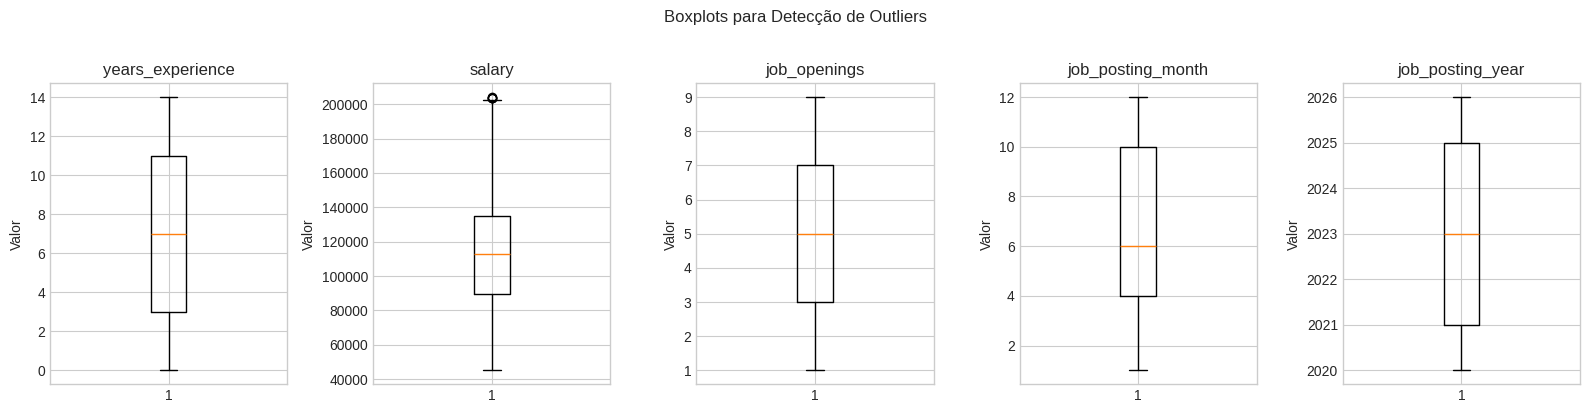


✓ Nota: Neste dataset, os outliers detectados pelo IQR são valores
  dentro de faixas razoáveis e não serão removidos.


In [57]:
# Análise de outliers usando método IQR
def detect_outliers_iqr(data, column):
    """Detecta outliers usando o método IQR (Interquartile Range)."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Variáveis numéricas para análise de outliers
numeric_for_outliers = ['years_experience', 'salary', 'job_openings', 'job_posting_month', 'job_posting_year']

print("Análise de Outliers (Método IQR):")
print("="*60)

outlier_summary = []
for col in numeric_for_outliers:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Variável': col,
        'Outliers': n_outliers,
        '% do Total': f"{pct:.2f}%",
        'Limite Inferior': f"{lower:.2f}",
        'Limite Superior': f"{upper:.2f}"
    })
    
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# Visualização de outliers com boxplots
fig, axes = plt.subplots(1, len(numeric_for_outliers), figsize=(16, 4))
for i, col in enumerate(numeric_for_outliers):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots para Detecção de Outliers', y=1.02)
plt.tight_layout()
plt.savefig('../reports/outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Nota: Neste dataset, os outliers detectados pelo IQR são valores")
print("  dentro de faixas razoáveis e não serão removidos.")

### 3.9 Análise de Multicolinearidade (VIF)

Análise de Multicolinearidade - VIF (Variance Inflation Factor)

Resultados:
            Variável  VIF Interpretação
    years_experience  1.0         Baixa
        job_openings  1.0         Baixa
   job_posting_month  1.0         Baixa
    job_posting_year  1.0         Baixa
       skills_python  1.0         Baixa
          skills_sql  1.0         Baixa
           skills_ml  1.0         Baixa
skills_deep_learning  1.0         Baixa
        skills_cloud  1.0         Baixa


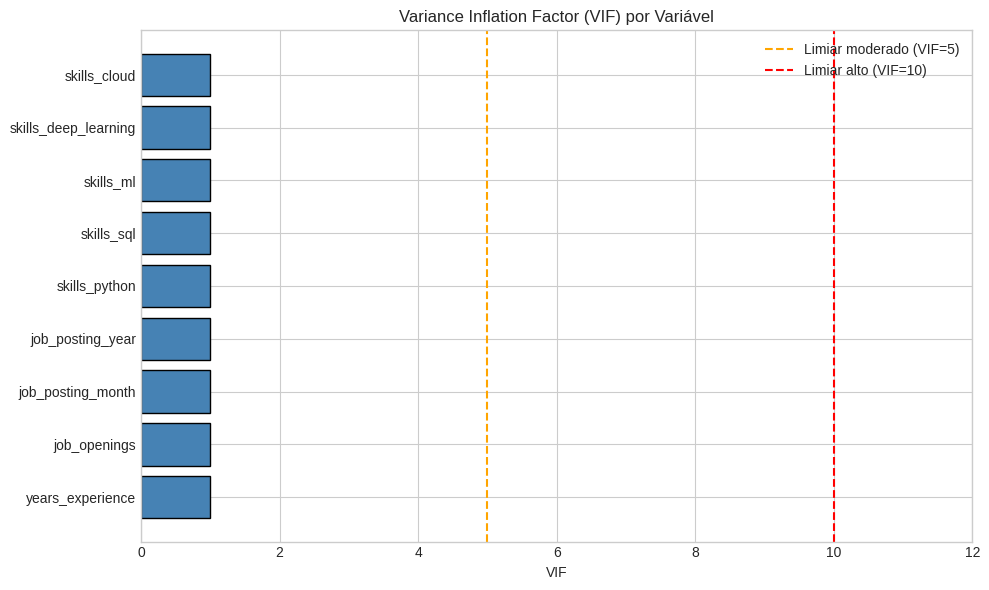


✓ Nenhuma variável apresenta multicolinearidade problemática (VIF < 5).


In [58]:
from statsmodels.tools.tools import add_constant

# Selecionar variáveis numéricas e binárias
numeric_cols_vif = ['years_experience', 'job_openings', 'job_posting_month', 'job_posting_year',
                    'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Criar matriz com a constante indispensável para o cálculo correto no statsmodels
X_vif_with_const = add_constant(df[numeric_cols_vif])

# Calcular VIF para cada variável
vif_data = []
for col in numeric_cols_vif:
    idx = list(X_vif_with_const.columns).index(col)
    vif_value = variance_inflation_factor(X_vif_with_const.values, idx)
    vif_data.append({
        'Variável': col,
        'VIF': round(vif_value, 2),
        'Interpretação': 'Alta' if vif_value > 10 else ('Moderada' if vif_value > 5 else 'Baixa')
    })

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("Análise de Multicolinearidade - VIF (Variance Inflation Factor)")
print("="*65)
print("\nResultados:")
print(vif_df.to_string(index=False))

# Visualização
plt.figure(figsize=(10, 6))
colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_df['VIF']]
plt.barh(vif_df['Variável'], vif_df['VIF'], color=colors, edgecolor='black')
plt.axvline(x=5, color='orange', linestyle='--', label='Limiar moderado (VIF=5)')
plt.axvline(x=10, color='red', linestyle='--', label='Limiar alto (VIF=10)')
plt.xlim(0, 12)
plt.xlabel('VIF')
plt.title('Variance Inflation Factor (VIF) por Variável')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusão
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ Variáveis com VIF > 5: {list(high_vif['Variável'])}")
else:
    print("\n✓ Nenhuma variável apresenta multicolinearidade problemática (VIF < 5).")

---
## 4. Pré-processamento

### 4.1 Definição de Variáveis

In [59]:
# Remover job_id (identificador)
df_model = df.drop(columns=['job_id'])

# Definir X e y
X = df_model.drop(columns=['salary'])

#Discretiza salary em classes
y_c = pd.qcut(df_model['salary'], q=3, labels=['Baixo', 'Medio', 'Alto'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_c)

# Aplicar mapeamento ordinal manual (0=Baixo, 1=Medio, 2=Alto)
target_mapping = {'Baixo': 0, 'Medio': 1, 'Alto': 2}
y = y_c.map(target_mapping).astype(int)

# Salvar artefato de mapeamento para pós-processamento de inferências
joblib.dump(target_mapping, '../artifacts/target_mapping.pkl')

print('Mapeamento de classes:')

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i} = {class_name}")

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Target (y) unique: {np.unique(y)}")

Mapeamento de classes:
0 = Alto
1 = Baixo
2 = Medio
Features (X): (10345, 17)
Target (y): (10345,)
Target (y) unique: [0 1 2]


In [60]:
# Classificar as variáveis
# Variáveis numéricas (para padronização)
numeric_features = ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings']

# Variáveis binárias (já são 0/1)
binary_features = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Variáveis ordinais (têm ordem natural)
ordinal_features = ['experience_level', 'education_level', 'hiring_urgency']

# Variáveis nominais (sem ordem - One-Hot)
nominal_features = ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']

print("Variáveis por tipo:")
print(f"  Numéricas: {numeric_features}")
print(f"  Binárias: {binary_features}")
print(f"  Ordinais: {ordinal_features}")
print(f"  Nominais: {nominal_features}")

Variáveis por tipo:
  Numéricas: ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings']
  Binárias: ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
  Ordinais: ['experience_level', 'education_level', 'hiring_urgency']
  Nominais: ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']


### 4.2 Engenharia de Recursos (Feature Engineering)

In [61]:
# Criar a variável derivada 'total_skills'
# Justificativa: Profissionais com maior diversidade técnica tendem a alcançar faixas salariais superiores.
skills_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
X['total_skills'] = X[skills_cols].sum(axis=1)

print("Atributo derivado 'total_skills' criado com sucesso.")
print(f"Dimensão atualizada de X: {X.shape}")

Atributo derivado 'total_skills' criado com sucesso.
Dimensão atualizada de X: (10345, 18)


### 4.3 Pipeline de Pré-processamento

In [62]:
# Mapeamento das variaveis
numeric_features = ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings', 'total_skills']
binary_features = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
ordinal_features = ['experience_level', 'education_level', 'hiring_urgency']
nominal_features = ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']

# Definir ordens para variáveis ordinais
experience_order = ['Entry', 'Mid', 'Senior']
education_order = ['Bachelor', 'Master', 'PhD']
urgency_order = ['Low', 'Medium', 'High']

# Preprocessador
preprocessor = ColumnTransformer(
    transformers=[
        # Numéricas: StandardScaler
        ('num', StandardScaler(), numeric_features),
        
        # Binárias: manter como estão (passthrough)
        ('bin', 'passthrough', binary_features),
        
        # Ordinais: OrdinalEncoder
        ('ord', OrdinalEncoder(categories=[experience_order, education_order, urgency_order]), 
         ordinal_features),
        
        # Nominais: OneHotEncoder
        ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         nominal_features)
    ],
    remainder='drop'
)

print("Preprocessador criado!")

Preprocessador criado!


### 4.4 Divisão dos Dados

In [63]:
# Split treino/teste (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=SEED, stratify=y
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validação: {X_validation.shape[0]:,} amostras ({X_validation.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:     {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

Treino:    6,207 amostras (60%)
Validação: 2,069 amostras (20%)
Teste:     2,069 amostras (20%)


In [64]:
# Aplicar preprocessamento
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape após preprocessamento:")
print(f"  X_train:      {X_train_processed.shape}")
print(f"  X_validation: {X_validation_processed.shape}")
print(f"  X_test:       {X_test_processed.shape}")

Shape após preprocessamento:
  X_train:      (6207, 34)
  X_validation: (2069, 34)
  X_test:       (2069, 34)


In [65]:
# Salvar preprocessador
joblib.dump(preprocessor, '../artifacts/preprocessor.joblib')
print("Preprocessador salvo em: artifacts/preprocessor.joblib")

Preprocessador salvo em: artifacts/preprocessor.joblib


---
## 5. Modelagem Supervisionada

### 5.1 Função de Avaliação

In [66]:
def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name):
    """
    Avalia um modelo de classificação em treino, validação e teste.
    """
    # Previsões
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Métricas de treino
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    
    # Métricas de validação
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='macro')
    
    # Métricas de teste
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='macro')
    test_recall = recall_score(y_test, y_test_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    
    print(f"\n{'='*50}")
    print(f"Modelo: {model_name}")
    print(f"{'='*50}")
    print(f"\nTREINO:")
    print(f"  Acurácia: {train_acc:.4f}")
    print(f"  F1-macro: {train_f1:.4f}")
    print(f"\nVALIDAÇÃO:")
    print(f"  Acurácia: {val_acc:.4f}")
    print(f"  F1-macro: {val_f1:.4f}")
    print(f"\nTESTE:")
    print(f"  Acurácia:          {test_acc:.4f}")
    print(f"  Acurácia Balanc.:  {test_bal_acc:.4f}")
    print(f"  Precisão (macro):  {test_precision:.4f}")
    print(f"  Revocação (macro): {test_recall:.4f}")
    print(f"  F1-Score (macro):  {test_f1:.4f}")
    
    return {
        'model_name': model_name,
        'train_accuracy': train_acc,
        'train_f1_macro': train_f1,
        'val_accuracy': val_acc,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1_macro': test_f1
    }

### 5.2 Modelo 1: Baseline (Classe Majoritária)

In [67]:
baseline_model = DummyClassifier(strategy="most_frequent", random_state=SEED)
baseline_model.fit(X_train_processed, y_train)

baseline_results = evaluate_model(
    baseline_model, 
    X_train_processed, X_validation_processed,X_test_processed,  # X_test vem antes
    y_train, y_validation, y_test, 
    'Baseline (Majoritária)'
)


Modelo: Baseline (Majoritária)

TREINO:
  Acurácia: 0.3335
  F1-macro: 0.1667

VALIDAÇÃO:
  Acurácia: 0.3335
  F1-macro: 0.1667

TESTE:
  Acurácia:          0.3330
  Acurácia Balanc.:  0.3333
  Precisão (macro):  0.1110
  Revocação (macro): 0.3333
  F1-Score (macro):  0.1665


### 5.3 Modelo 2: Modelo Linear (Logistic Regression)

In [68]:
# Treinar modelo
lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
lr_model.fit(X_train_processed, y_train)

lr_results = evaluate_model(lr_model, X_train_processed, X_validation_processed, X_test_processed,
                            y_train, y_validation, y_test, 'Logistic Regression')


Modelo: Logistic Regression

TREINO:
  Acurácia: 0.9383
  F1-macro: 0.9387

VALIDAÇÃO:
  Acurácia: 0.9319
  F1-macro: 0.9324

TESTE:
  Acurácia:          0.9323
  Acurácia Balanc.:  0.9323
  Precisão (macro):  0.9367
  Revocação (macro): 0.9323
  F1-Score (macro):  0.9332


### 5.4 Modelo 3: Random Forest

In [69]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)

rf_results = evaluate_model(rf_model, X_train_processed, X_validation_processed, X_test_processed,y_train, y_validation, y_test, "Random Forest")


Modelo: Random Forest

TREINO:
  Acurácia: 0.9457
  F1-macro: 0.9456

VALIDAÇÃO:
  Acurácia: 0.8400
  F1-macro: 0.8394

TESTE:
  Acurácia:          0.8531
  Acurácia Balanc.:  0.8531
  Precisão (macro):  0.8584
  Revocação (macro): 0.8531
  F1-Score (macro):  0.8525


### 5.5 Modelo 4: XGBoost

In [70]:
# Treinar modelo
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_processed, y_train)

# Avaliar
xgb_results = evaluate_model(xgb_model, X_train_processed, X_validation_processed, X_test_processed, 
                             y_train, y_validation,y_test, 'XGBoost')


Modelo: XGBoost

TREINO:
  Acurácia: 0.9791
  F1-macro: 0.9791

VALIDAÇÃO:
  Acurácia: 0.9280
  F1-macro: 0.9284

TESTE:
  Acurácia:          0.9333
  Acurácia Balanc.:  0.9333
  Precisão (macro):  0.9352
  Revocação (macro): 0.9333
  F1-Score (macro):  0.9338


In [71]:
print("lr_results:", lr_results)
print("rf_results:", rf_results)
print("xgb_results:", xgb_results)

lr_results: {'model_name': 'Logistic Regression', 'train_accuracy': 0.9382954728532302, 'train_f1_macro': np.float64(0.9387144657327685), 'val_accuracy': 0.931851135814403, 'val_f1_macro': np.float64(0.9324118262297479), 'test_accuracy': 0.9323344610923151, 'test_balanced_accuracy': np.float64(0.9323327934484621), 'test_precision': np.float64(0.9366929704739801), 'test_recall': np.float64(0.9323327934484621), 'test_f1_macro': np.float64(0.9331742846459328)}
rf_results: {'model_name': 'Random Forest', 'train_accuracy': 0.9457064604478814, 'train_f1_macro': np.float64(0.945637315155858), 'val_accuracy': 0.8400193330111165, 'val_f1_macro': np.float64(0.8393882621934182), 'test_accuracy': 0.8530691155147414, 'test_balanced_accuracy': np.float64(0.8531148552477511), 'test_precision': np.float64(0.8584083625981759), 'test_recall': np.float64(0.8531148552477511), 'test_f1_macro': np.float64(0.8525406329222021)}
xgb_results: {'model_name': 'XGBoost', 'train_accuracy': 0.9790559046238119, 'trai

### 5.6 Comparação dos Modelos

In [72]:
# Criar DataFrame com resultados
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.set_index('model_name')

print("\nComparação dos Modelos:")
print(results_df.round(3))


Comparação dos Modelos:
                     train_accuracy  train_f1_macro  val_accuracy  \
model_name                                                          
Logistic Regression           0.938           0.939         0.932   
Random Forest                 0.946           0.946         0.840   
XGBoost                       0.979           0.979         0.928   

                     val_f1_macro  test_accuracy  test_balanced_accuracy  \
model_name                                                                 
Logistic Regression         0.932          0.932                   0.932   
Random Forest               0.839          0.853                   0.853   
XGBoost                     0.928          0.933                   0.933   

                     test_precision  test_recall  test_f1_macro  
model_name                                                       
Logistic Regression           0.937        0.932          0.933  
Random Forest                 0.858        0.853  

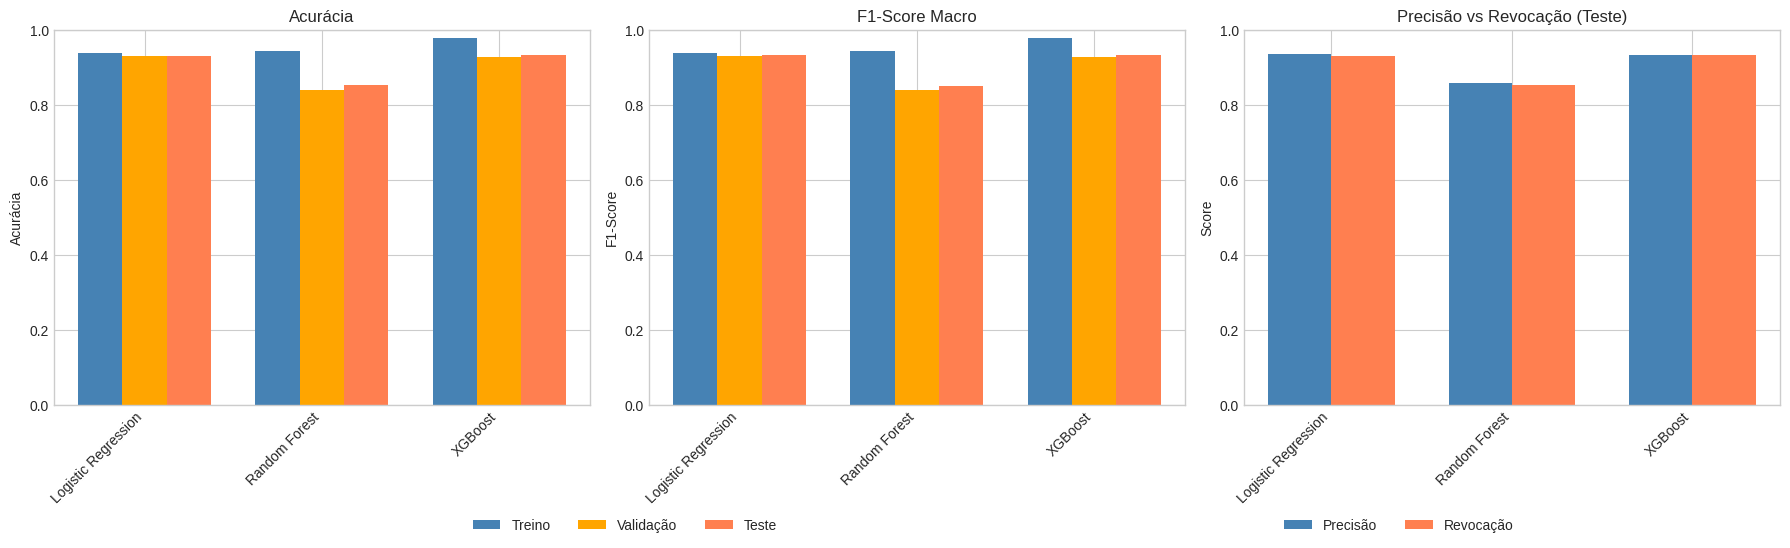

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df.index.tolist()
x = np.arange(len(models))
width = 0.25

# Acurácia
axes[0].bar(x - width, results_df['train_accuracy'], width, label='Treino', color='steelblue')
axes[0].bar(x, results_df['val_accuracy'], width, label='Validação', color='orange')
axes[0].bar(x + width, results_df['test_accuracy'], width, label='Teste', color='coral')
axes[0].set_title('Acurácia')
axes[0].set_ylabel('Acurácia')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylim(0, 1)

# F1-Score
axes[1].bar(x - width, results_df['train_f1_macro'], width, label='Treino', color='steelblue')
axes[1].bar(x, results_df['val_f1_macro'], width, label='Validação', color='orange')
axes[1].bar(x + width, results_df['test_f1_macro'], width, label='Teste', color='coral')
axes[1].set_title('F1-Score Macro')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1)

# Precisão vs Revocação (Teste)
width2 = 0.35
axes[2].bar(x - width2/2, results_df['test_precision'], width2, label='Precisão', color='steelblue')
axes[2].bar(x + width2/2, results_df['test_recall'], width2, label='Revocação', color='coral')
axes[2].set_title('Precisão vs Revocação (Teste)')
axes[2].set_ylabel('Score')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].set_ylim(0, 1)

# Legendas
from matplotlib.patches import Patch
legend1 = [Patch(facecolor='steelblue', label='Treino'),
           Patch(facecolor='orange', label='Validação'),
           Patch(facecolor='coral', label='Teste')]

fig.legend(handles=legend1, loc='lower center', ncol=3, bbox_to_anchor=(0.35, -0.1))

legend2 = [Patch(facecolor='steelblue', label='Precisão'),
           Patch(facecolor='coral', label='Revocação')]
fig.legend(handles=legend2, loc='lower center', ncol=2, bbox_to_anchor=(0.78, -0.1))

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Otimização de Hiperparâmetros

In [74]:
# GridSearchCV no Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Iniciando GridSearchCV...")
print(f"Total de combinações: {3 * 4 * 3 * 3} = 108")

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("\nGridSearchCV concluído!")

Iniciando GridSearchCV...
Total de combinações: 108 = 108
Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearchCV concluído!


In [75]:
# Melhores parâmetros
print("Melhores hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMelhor RMSE (CV): ${-grid_search.best_score_:,.2f}")

Melhores hiperparâmetros:
  max_depth: 15
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 200

Melhor RMSE (CV): $0.26


In [76]:
# Avaliar modelo otimizado
best_rf_model = grid_search.best_estimator_

best_rf_results = evaluate_model(best_rf_model, X_train_processed, X_test_processed, 
                                  y_train, y_test, 'Random Forest (Otimizado)')

TypeError: evaluate_model() missing 2 required positional arguments: 'y_test' and 'model_name'

Exception ignored in: <function ResourceTracker.__del__ at 0x73072c17f4c0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7a38834634c0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x726cd82674c0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

In [ ]:
# Salvar melhor modelo
joblib.dump(best_rf_model, '../models/best_random_forest.joblib')
print("Modelo salvo em: models/best_random_forest.joblib")

### 6.1 Feature Importance

In [ ]:
# Obter nomes das features após transformação
feature_names = (
    numeric_features + 
    binary_features + 
    ordinal_features + 
    list(preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_features))
)

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 15 features
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importância')
plt.title('Top 15 Features Mais Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Modelagem Não Supervisionada

### 7.1 PCA - Redução de Dimensionalidade

In [ ]:
# Aplicar PCA
pca = PCA(random_state=SEED)
X_pca_full = pca.fit_transform(X_train_processed)

# Variância explicada
variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variância por componente
axes[0].bar(range(1, len(variance_ratio[:20]) + 1), variance_ratio[:20], 
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('Variância por Componente (Top 20)')

# Variância cumulativa
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
             marker='o', color='steelblue')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% variância')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variância')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Cumulativa')
axes[1].set_title('Variância Cumulativa Explicada')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Encontrar número de componentes para 95% da variância
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponentes para 95% da variância: {n_components_95}")

In [ ]:
# PCA com 2 componentes para visualização
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train_processed)

# Visualizar com cores por faixa salarial
salary_bins = pd.cut(y_train, bins=3, labels=['Baixo', 'Médio', 'Alto'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=salary_bins.cat.codes, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Faixa Salarial (0=Baixo, 1=Médio, 2=Alto)')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variância)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variância)')
plt.title('PCA - Visualização 2D (colorido por faixa salarial)')
plt.tight_layout()
plt.savefig('../reports/pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 K-Means Clustering

In [ ]:
# Método do cotovelo para determinar número de clusters
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_train_processed)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo - K-Means')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('../reports/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Aplicar K-Means com k=4 (baseado no cotovelo)
N_CLUSTERS = 4

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_train_processed)

print(f"Clusters encontrados: {N_CLUSTERS}")
print(f"\nDistribuição dos clusters:")
print(pd.Series(clusters).value_counts().sort_index())

In [ ]:
# Visualizar clusters no espaço PCA 2D
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=clusters, cmap='Set1', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variância)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variância)')
plt.title('K-Means Clustering (visualização PCA 2D)')
plt.tight_layout()
plt.savefig('../reports/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Análise dos clusters - perfil médio
X_train_with_clusters = X_train.copy()
X_train_with_clusters['cluster'] = clusters
X_train_with_clusters['salary'] = y_train.values

# Estatísticas por cluster
print("Perfil médio por cluster:")
print("="*60)

for cluster_id in range(N_CLUSTERS):
    cluster_data = X_train_with_clusters[X_train_with_clusters['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_data):,} vagas):")
    print(f"  Salário médio: ${cluster_data['salary'].mean():,.0f}")
    print(f"  Anos experiência (média): {cluster_data['years_experience'].mean():.1f}")
    print(f"  Cargo mais comum: {cluster_data['job_title'].mode().values[0]}")
    print(f"  País mais comum: {cluster_data['country'].mode().values[0]}")
    print(f"  Nível mais comum: {cluster_data['experience_level'].mode().values[0]}")

In [ ]:
# Boxplot de salário por cluster
plt.figure(figsize=(10, 6))
X_train_with_clusters.boxplot(column='salary', by='cluster', figsize=(10, 6))
plt.title('Distribuição de Salário por Cluster')
plt.suptitle('')
plt.xlabel('Cluster')
plt.ylabel('Salário (USD)')
plt.tight_layout()
plt.savefig('../reports/salary_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Salvar modelo K-Means
joblib.dump(kmeans, '../models/kmeans_model.joblib')
joblib.dump(pca_2d, '../artifacts/pca_2d.joblib')
print("Modelos não supervisionados salvos!")

---
## 8. Conclusões

In [ ]:
# Resumo final dos resultados
print("="*60)
print("RESUMO DO PROJETO")
print("="*60)

print("\n1. DATASET")
print(f"   - Total de registros: {len(df):,}")
print(f"   - Total de features: {X.shape[1]}")
print(f"   - Features após encoding: {X_train_processed.shape[1]}")

print("\n2. MODELAGEM SUPERVISIONADA")
print(f"   Melhor modelo: Random Forest (Otimizado)")
print(f"   - RMSE (teste): ${best_rf_results['test_rmse']:,.2f}")
print(f"   - MAE (teste):  ${best_rf_results['test_mae']:,.2f}")
print(f"   - R² (teste):   {best_rf_results['test_r2']:.4f}")

print("\n3. MODELAGEM NÃO SUPERVISIONADA")
print(f"   - PCA: {n_components_95} componentes para 95% da variância")
print(f"   - K-Means: {N_CLUSTERS} clusters identificados")

print("\n4. ARTEFATOS SALVOS")
print("   - models/best_random_forest.joblib")
print("   - models/kmeans_model.joblib")
print("   - artifacts/preprocessor.joblib")
print("   - artifacts/pca_2d.joblib")
print("   - reports/*.png (gráficos)")

In [ ]:
# Validação cruzada final do melhor modelo
print("\nValidação Cruzada (5-fold) do Melhor Modelo:")
cv_scores = cross_val_score(best_rf_model, X_train_processed, y_train, 
                            cv=5, scoring='neg_root_mean_squared_error')
print(f"  RMSE médio: ${-cv_scores.mean():,.2f} (+/- ${cv_scores.std() * 2:,.2f})")

### Limitações e Próximos Passos

**Limitações identificadas:**
1. Dataset possivelmente sintético (valores muito regulares, anos futuros como 2026)
2. Inconsistências nos dados (Entry-level com 14 anos de experiência)
3. Não há informações sobre benefícios, localização específica ou tipo de contrato

**Possíveis melhorias:**
1. Feature engineering adicional (ex: combinar skills em índice)
2. Testar outros modelos (LightGBM, CatBoost)
3. Análise de resíduos mais detalhada
4. Validar com dados reais do mercado